# Find alpha for cherry table that produces endpoints for vanilla tables alpha = 0.95

## imports

In [6]:
from math import log, e, sqrt
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.patches as mpatches

## Constants

In [7]:
N = 2 ** 16
p = 1-e**-2 # our table coverage
cost_factors = range(5, 31, 5)  # cost factors to simulate
alpha = 0.95  # maximality factor
alphas = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
t = round(log(1-p)/log(1-N**(-1/3)))

## Get expected vanilla values

In [8]:
# calculate expected m_t
expected_mts = []
# mt-max = 2N/t+2
# mt = alpha * mt-max
t = round(log(1-p)/log(1-N**(-1/3)))
mt_max = (2*N)/(t + 2)
for alpha in alphas:
    expected_mts.append(round(alpha * mt_max))

## Cherry Sampling

In [9]:
def get_mean(N, m):
    return N - (N*(1 - 1/N)**m)

def get_std(N, m):
    # E1 and E2
    E1 = (1 - 1 / N) ** m
    E2 = (1 - 2 / N) ** m

    return sqrt(N * (((N - 1) * E2) + E1 - (N * (E1 ** 2))))

# Cherry Table Simulation - only returns number of endpoints
def cherry_table_simulation(N, t, K, startpoints_len):

    m = startpoints_len

    # for each column
    for i in range(len(K)):
        # get the mean (loc)
        # get the standard deviation (scale)
        mean = get_mean(N, m)
        std = get_std(N, m)
        # get distribution of the current column
        column_dist = norm(loc=mean, scale=std)
        # for the next column, we want to sample K times and use the maximum
        samples = column_dist.rvs(size=round(K[i]))
        # set m to be the maximum of these samples
        m = max(samples)


    return m

### Get Samples

In [10]:
cherry_sample_simulated_mts = []

# get kis for each alpha
with open("data/cherry_N_16_different_alpha_0.5_0.95_optimisation_results.pkl", "rb") as f:
    optimisation_results = pickle.load(f)

K = [optimisation_results[i][0] for i in range(len(alphas))]

for alpha in alphas:

    mts = []

    mt_max = (2*N)/(t+2)
    mt_target = alpha * mt_max
    cherry_m_0 = round(mt_target/(1-alpha))    # our starting m_0

    # get the kis for this alpha
    kis_for_alpha = K[alphas.index(alpha)]

    # run 100 simulations
    for _ in range(100):
        mt = cherry_table_simulation(N, t, kis_for_alpha, cherry_m_0)
        mts.append(mt)

    cherry_sample_simulated_mts.append(mts)

In [11]:
# do sampling for vanilla tables as well
vanilla_sample_simulated_mts = []
K = [1 for i in range(t)]  # all kis are 1 for vanilla tables

for alpha in alphas:

    mts = []

    mt_max = (2*N)/(t+2)
    mt_target = alpha * mt_max
    vanilla_m_0 = round(mt_target/(1-alpha))    # our starting m_0

    # run 100 simulations
    for _ in range(100):
        mt = cherry_table_simulation(N, t, K, vanilla_m_0)
        mts.append(mt)

    vanilla_sample_simulated_mts.append(mts)

## Plot

Intersection point at alpha = 0.6235306828003457


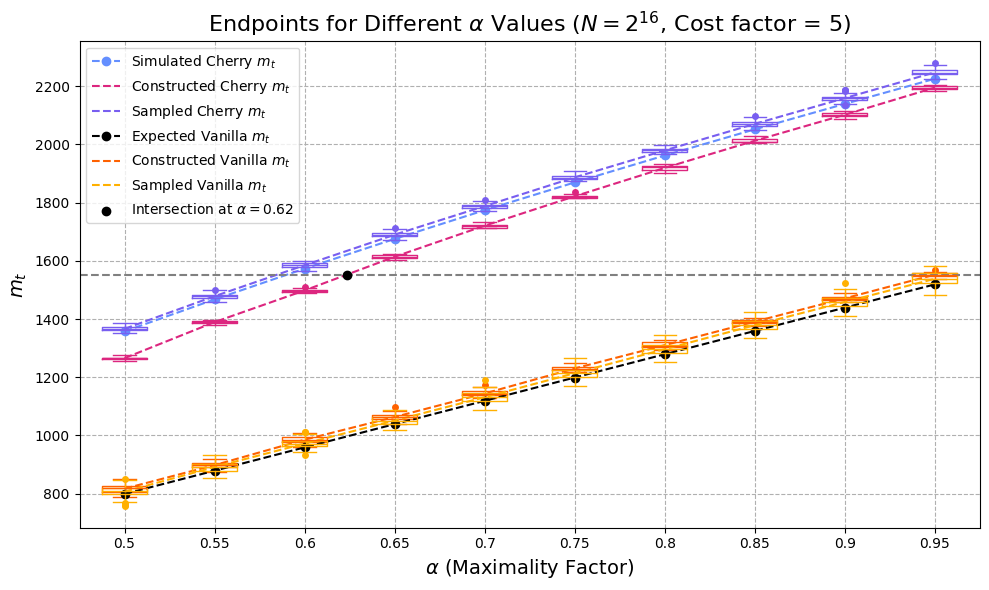

In [14]:
# plot scatter plot of optimisation mt vs generated mt
x_indicies = range(len(alphas))
plt.figure(figsize=(10,6))


# # read in from file for cherry tables
data_cherry = pd.read_csv("data/cherry_N_16_10_trials_different_alpha_0.5_0.95_with_cost_results.csv")
plt.plot(x_indicies, data_cherry['optimiser_mt'], color='#648FFF', label='Simulated Cherry $m_t$', linestyle='--', marker='o')
# plot box plot for actual cherry mt from 10 trials
plt.boxplot([data_cherry.loc[data_cherry['alpha'] == alpha, data_cherry.columns[2:12]].values.flatten() for alpha in alphas], 
            positions=x_indicies, widths=0.5,
            boxprops=dict(color='#DC267F'),      
            medianprops=dict(color='#DC267F'),
            whiskerprops=dict(color='#DC267F'),
            capprops=dict(color='#DC267F'),
            flierprops=dict(markerfacecolor='#DC267F', marker='o', markersize=5, markeredgecolor='none'))
# plot means of cherry boxplots
plt.plot(x_indicies, [data_cherry.loc[data_cherry['alpha'] == alpha, data_cherry.columns[2:12]].values.flatten().mean() for alpha in alphas], 
         color='#DC267F', linestyle='--', label='Constructed Cherry $m_t$')


# plot the cherry sampling method too as a boxplot
plt.boxplot(cherry_sample_simulated_mts, 
            positions=[i for i in x_indicies], widths=0.5,
            boxprops=dict(color='#785EF0'),  
            medianprops=dict(color='#785EF0'),
            whiskerprops=dict(color='#785EF0'),
            capprops=dict(color='#785EF0'),
            flierprops=dict(markerfacecolor='#785EF0', marker='o', markersize=5, markeredgecolor='none'))
# plot means of cherry sampling boxplots
plt.plot([i for i in x_indicies], [np.mean(cherry_sample_simulated_mts[a]) for a in range(len(alphas))], 
         color='#785EF0', linestyle='--', label='Sampled Cherry $m_t$')



# plot actual for vanilla tables as well
data_vanilla = pd.read_csv("data/vanilla_N_16_different_alpha_0.5_0.95_with_cost_results.csv")
x_indicies = range(len(alphas))
# for actual vanilla - convert samples from dataframe to a single list for boxplot
plt.boxplot([data_vanilla.loc[data_vanilla['alpha'] == alpha, data_vanilla.columns[2:22]].values.flatten() for alpha in alphas], 
            positions=x_indicies, widths=0.5,
            boxprops=dict(color='#FE6100'),
            medianprops=dict(color='#FE6100'),
            whiskerprops=dict(color='#FE6100'),
            capprops=dict(color='#FE6100'),
            flierprops=dict(markerfacecolor='#FE6100', marker='o', markersize=5, markeredgecolor='none'))
# plot expected vanilla mt in green
plt.plot(x_indicies, expected_mts, color='k', label='Expected Vanilla $m_t$', marker='o', linestyle='--')
# plot means of vanilla boxplots
plt.plot(x_indicies, [data_vanilla.loc[data_vanilla['alpha'] == alpha, data_vanilla.columns[2:22]].values.flatten().mean() for alpha in alphas], 
         color='#FE6100', linestyle='--', label='Constructed Vanilla $m_t$')

# plot the vanilla sampling method too as a boxplot
plt.boxplot(vanilla_sample_simulated_mts, 
            positions=[i for i in x_indicies], widths=0.5,
            boxprops=dict(color='#FFB000'),  
            medianprops=dict(color='#FFB000'),
            whiskerprops=dict(color='#FFB000'),
            capprops=dict(color='#FFB000'),
            flierprops=dict(markerfacecolor='#FFB000', marker='o', markersize=5, markeredgecolor='none'))
# plot means of vanilla sampling boxplots
plt.plot([i for i in x_indicies], [np.mean(vanilla_sample_simulated_mts[a]) for a in range(len(alphas))], 
         color='#FFB000', linestyle='--', label='Sampled Vanilla $m_t$')


# draw a line from vanilla expected at 0.95 alpha and see what alpha it lands on for constructed cherry mt
y_point = data_vanilla.loc[data_vanilla['alpha'] == 0.95, data_vanilla.columns[2:22]].values.flatten().mean()
plt.axhline(y=y_point, color='grey', linestyle='--')
# label the alpha it lands on on the constructed cherry mt line
# find the intersection point of the horizontal line with the constructed cherry mt line
# y_point = expected_mts[-1]
# what if y point was mean of actual vanilla mt at 0.95 alpha instead?

x2 = x_indicies
# y2 is the means of the cherry boxplots
y2 = [data_cherry.loc[data_cherry['alpha'] == alpha, data_cherry.columns[2:12]].values.flatten().mean() for alpha in alphas]

from scipy.interpolate import interp1d
interp_func = interp1d(y2, x2, bounds_error=False, fill_value='extrapolate')
x_intersect = interp_func(y_point)

# mark point of intersection on plot
# for label need to convert x_intersect back to alpha value
# find what alpha it corresponds to as if the x axis is a continuous line rather than discrete points
x_intersect_alpha = np.interp(x_intersect, x_indicies, alphas)
print(f"Intersection point at alpha = {x_intersect_alpha}")

plt.scatter(x_intersect, y_point, color='black', label=f'Intersection at $\\alpha={x_intersect_alpha:.2f}$', zorder=5)



# titles and labels
plt.xlabel('$\\alpha$ (Maximality Factor)', fontsize=14)
plt.ylabel('$m_t$', fontsize=14)
plt.xticks(x_indicies, alphas)
plt.grid(linestyle="--")
plt.title('Endpoints for Different $\\alpha$ Values ($N=2^{16}$, Cost factor = 5)', fontsize=16)

# manually add legend
box_legend = mpatches.Patch(color="#FE6100", label="Vanilla Actual $m_t$")
# plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label='Actual $m_t$', markerfacecolor='dodgerblue', markersize=10), plt.Line2D([0], [0], marker='o', color='w', label='Simulated $m_t$', markerfacecolor='orange', markersize=10), box_legend, plt.Line2D([0], [0], marker='o', color='w', label='Expected Vanilla $m_t$', markerfacecolor='green', markersize=10)])
plt.legend()
plt.tight_layout()  
# # save plot as svg
# plt.savefig("cherry_vanilla_simulated_vs_actual_mts_alpha_comparison.svg", format='svg')
# save plot as pdf
# plt.savefig("cherry_vanilla_simulated_vs_actual_mts_alpha_comparison.pdf", format='pdf')
plt.show()